In [ ]:
import seaborn as sns
data=sns.load_dataset("titanic")

data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
data.shape

(891, 15)

In [ ]:
data['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

#checking for missing values

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
data.values.any()

np.True_

In [ ]:
data.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


handling missing values by deleting the rows with missing values

In [ ]:
data_1=data.dropna()
data_1.shape

(182, 15)

#columnwise deletion

In [ ]:
data_2=data.dropna(axis=1)
data_2.shape

(891, 11)

In [ ]:
data_2.head()

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True


#handling missing values

<Axes: xlabel='age', ylabel='Count'>

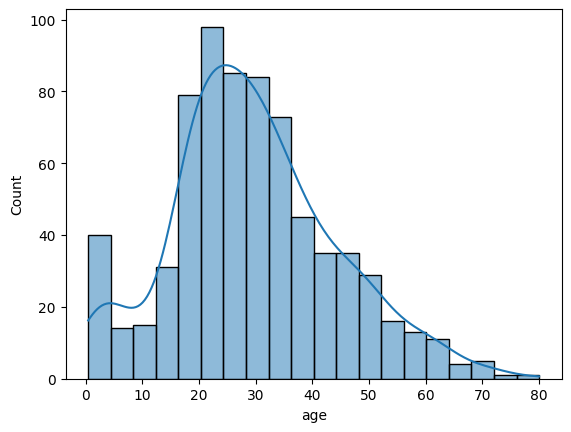

In [ ]:
sns.histplot(data['age'],kde=True)

#**Mean imputation**

data[age_mean] is creating new column

In [ ]:
data['age_mean']=data['age'].fillna(data['age'].mean())

data[["age","age_mean"]]

,age,age_mean
0,22.0,22.000000
1,38.0,38.000000
2,26.0,26.000000
3,35.0,35.000000
4,35.0,35.000000
...,...,...
886,27.0,27.000000
887,19.0,19.000000
888,NaN,29.699118
889,26.0,26.000000


#**median Imputation**

In [ ]:
data["age_median"]=data['age'].fillna(data['age'].median())
data[["age","age_median"]]

,age,age_median
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
...,...,...
886,27.0,27.0
887,19.0,19.0
888,NaN,28.0
889,26.0,26.0


#**Mode imputation**

In [ ]:
data["embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
data["embarked"].value_counts()

,count
embarked,
S,644
C,168
Q,77


In [ ]:
data[data['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [ ]:
data["embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
data['embarked_mode']=data["embarked"].fillna(data["embarked"].mode())

data["embarked"].value_counts()

,count
embarked,
S,644
C,168
Q,77


data["embarked"].mode() returns a Series, not a single value. Since mode() can return multiple values (if there's a tie for the most frequent value), fillna() does not work as expected.

The .fillna() method requires a scalar value, but you're passing a Series.

In [ ]:
data['embarked_mode'] = data["embarked"].fillna(data["embarked"].mode().iloc[0])

data["embarked_mode"].value_counts()

,count
embarked_mode,
S,646
C,168
Q,77


In [ ]:
data["embarked"].mode()

,embarked
0,S


In [ ]:
data['embarked_mode'][61]

'S'

In [ ]:
data[["embarked","embarked_mode"]]



,embarked,embarked_mode
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


#**handling imbalanced dataset**

The function np.random.seed(123) sets the seed for NumPy’s random number generator. This ensures that random operations produce the same results every time the code is run.

In [ ]:
import pandas as pd
import numpy as np

#set the random seed for reproducibility

np.random.seed(123)

#create a dataframe with two classes
n_samples=1000
class_0_ratio=.9
n_class_0=int(n_samples*class_0_ratio)
n_class_1=n_samples-n_class_0

In [ ]:
n_class_0,n_class_1

(900, 100)

DATA FOR CLASS 0

creating a dataframe with imbalanced dataset


data for class 0

np.random.normal(loc=0, scale=1, size=n_class_0) generates random numbers from a normal distribution (Gaussian distribution).

loc=0: The mean of the normal distribution is 0.

scale=1: The standard deviation is 1, meaning most values will be close to 0.

size=n_class_0: Generates n_class_0 values (900 in this case).

[0] * n_class_0 creates a list of 0s with length n_class_0 (900 zeros).

These values represent the class label for this dataset (Class 0).

The dataset is imbalanced (90% Class 0, 10% Class 1).



In [ ]:
class_0=pd.DataFrame({
    "feature_1":np.random.normal(loc=0,scale=1,size=n_class_0),
    "feature_2":np.random.normal(loc=0,scale=1,size=n_class_0),
    "target":[0]*n_class_0
})

class_0.shape

(900, 3)

In [ ]:
class_0.head(10)

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0
5,1.651437,-0.116932,0
6,-2.426679,-0.102391,0
7,-0.428913,-2.272618,0
8,1.265936,-0.642610,0
9,-0.866740,0.299885,0


DATA FOR CLASS 1

In [ ]:
class_1=pd.DataFrame({
    "feature_1":np.random.normal(loc=2,scale=1,size=n_class_1),
    "feature_2":np.random.normal(loc=2,scale=1,size=n_class_1),
    "target":[1]*n_class_1
})

In [ ]:
class_1.shape

(100, 3)

In [ ]:
class_1.head()

,feature_1,feature_2,target
0,1.699768,2.139033,1
1,1.367739,2.025577,1
2,1.795683,1.803557,1
3,2.213696,3.312255,1
4,3.033878,3.187417,1


In [ ]:
df=pd.concat([class_0,class_1])  #row wise concatenation

df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


After concatenation, pandas retains the original row indices from class_0 and class_1, which may result in duplicate or unordered indices.

.reset_index(drop=True) does the following:

Resets the index to a new sequential order (0, 1, 2, …).

drop=True ensures that the old index is not added as a separate column.

This is crucial because if we don’t reset the index, we may end up with a dataset where the index numbers are inconsistent.

In [ ]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)

df.shape

(1000, 3)

In [ ]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [ ]:
df.tail()


,feature_1,feature_2,target
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1
999,2.697490,2.013570,1


In [ ]:
df['target'].unique()

array([0, 1])

In [ ]:
df['target'].value_counts()

,count
target,
0,900
1,100


#**upsampling**

In [ ]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

print(df_minority.shape,df_majority.shape)

(100, 3) (900, 3)


1. from sklearn.utils import resample
sklearn.utils.resample is a function that helps in resampling datasets, commonly used for upsampling or downsampling.

It is useful for handling imbalanced datasets, where one class has significantly fewer samples than the other.



2. df_minority_upsampled = resample(...)
This creates a new DataFrame (df_minority_upsampled) by resampling the minority class (df_minority).

The goal here is to increase the number of minority class samples to match the majority class.

3. replace=True → Sampling with Replacement

replace=True
Enables bootstrapping (sampling with replacement), meaning the same sample can be picked multiple times.

This is necessary when upsampling, since we need more samples than we originally have.

Without replace=True, we would be limited to the existing data and couldn't increase its size.

4. n_samples=len(df_majority) → Match Majority Class Size

n_samples=len(df_majority)
Specifies that the new dataset (df_minority_upsampled) should have the same number of samples as the majority class (df_majority).

This is important for balancing the dataset, ensuring that both classes contribute equally to training a machine learning model.

5. random_state=42 → Ensuring Reproducibility

random_state=42
Fixes the random seed, ensuring that every time you run this code, the same random samples are selected.

This helps in reproducibility, meaning the results will be the same when the code is executed multiple times.

In [ ]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True, #Sample with replacement
                            n_samples=len(df_majority),
                               random_state=42)

In [ ]:
df_minority_upsampled.shape

(900, 3)

In [ ]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,1.125854,1.843917,1
992,2.196570,1.397425,1
914,1.932170,2.998053,1
971,2.272825,3.034197,1
960,2.870056,1.550485,1


In [ ]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

df_upsampled.shape

(1800, 3)

In [ ]:
df_upsampled.tail()

,feature_1,feature_2,target
952,1.188902,2.189189,1
965,3.919526,1.980541,1
976,2.810326,3.604614,1
942,3.621531,2.168229,1
974,1.160887,2.489203,1


In [ ]:
df_upsampled['target'].value_counts()

,count
target,
0,900
1,900


#**DOWNSAMPLING**

why we use replce =false in downsa,mpling

1. Avoiding Duplicates
replace=False ensures that each selected sample is unique (i.e., no repetition).

Since we are selecting fewer samples (not more than what exists), we don’t need to duplicate data.

In [ ]:
df_majority_downsampled=resample(df_majority,replace=False,n_samples=len(df_minority),random_state=42)

In [ ]:
df_majority_downsampled.shape

(100, 3)

In [ ]:
df_downsampled=pd.concat([df_minority,df_majority_downsampled])

df_downsampled.shape

(200, 3)

In [ ]:
df_downsampled.head()

,feature_1,feature_2,target
900,1.699768,2.139033,1
901,1.367739,2.025577,1
902,1.795683,1.803557,1
903,2.213696,3.312255,1
904,3.033878,3.187417,1


In [ ]:
df_downsampled['target'].value_counts()

,count
target,
1,100
0,100


#**SMOTE (synthetic Minority Oversampling technique)**

SMOTE is a technique used in machine learning to address imbalanced datasets where the minority class has significantly fewer instances than the majority class. SMOTE involves generating synthetic instances of the minority class by interpolating between existing instances."

The function make_classification in Scikit-Learn is used to generate synthetic datasets for machine learning, specifically for classification tasks. It helps in creating structured datasets with defined properties, making it useful for testing models, experimentation, and research.



1. make_classification(...)
Purpose: Generates a synthetic dataset for classification tasks.

Significance: Helps create a dataset with controlled properties for testing and training machine learning models.

2. n_samples=1000
Meaning: The dataset will contain 1,000 samples (rows).

Significance: Determines the dataset size, useful for training models.

3. n_features=2
Meaning: The dataset will have 2 total features (columns).

Significance: Each sample will have 2 numerical features used to separate classes.

4. n_redundant=0
Meaning: There are no redundant (duplicate) features.

Significance: Ensures all features provide unique information, making classification clearer.

5. n_clusters_per_class=1
Meaning: Each class will form a single cluster in feature space.

Significance:

With one cluster per class, the classes are more separable.

Increasing this value would create multiple sub-clusters per class, making classification harder.

6. weights=[0.90]
Meaning: The first class (Class 0) will have 90% of the samples, and Class 1 will have the remaining 10%.

Significance: Creates an imbalanced dataset, which is useful for:

Testing imbalanced classification techniques (e.g., SMOTE, undersampling).

Evaluating the robustness of ML models against class imbalance.

7. random_state=12
Meaning: Ensures that the generated dataset is the same every time the code is run.

Significance: Useful for reproducibility, so that results remain consistent.

Final Dataset (X, y)
X (features): A (1000, 2) matrix, where each row has 2 feature values.

y (labels): A (1000, ) array containing the class labels (0 or 1), where 90% are 0 and 10% are 1.



In [ ]:
from sklearn.datasets import make_classification

x,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0.90],random_state=12)

type(x)

numpy.ndarray

In [ ]:
print(x)

[[-0.76289759 -0.70680807]
 [-1.07543571 -1.0511621 ]
 [-0.61011459 -0.90980157]
 ...
 [-1.32643852 -1.815178  ]
 [-0.83348573 -0.5146474 ]
 [-0.30287558 -0.57597532]]


In [ ]:
print(y)

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 

In [ ]:
y.shape

(1000,)

In [ ]:
x.shape

(1000, 2)

"series dont have column attribute so we use name to five column name

In [ ]:
import pandas as pd
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.Series(y,name="target")

final_df=pd.concat([df1,df2],axis=1)

final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [ ]:
final_df['target'].value_counts()

,count
target,
0,900
1,100


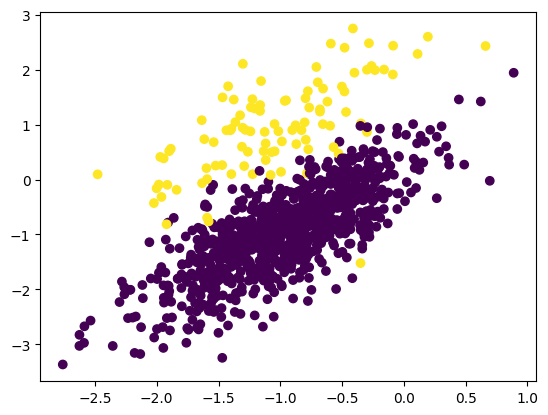

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
oversample=SMOTE()

x,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])



In [ ]:
x.shape

(1800, 2)

In [ ]:
y.shape

(1800,)

In [ ]:
len(y[y==0])

900

In [ ]:
len(y[y==1])

900

In [ ]:
data_smote=pd.concat([x,y],axis=1)
data_smote.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


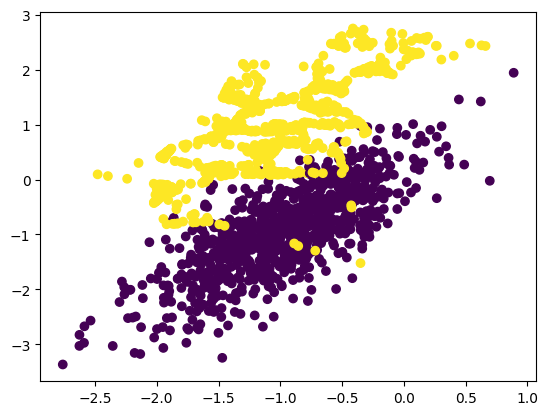

In [ ]:
plt.scatter(data_smote['f1'],data_smote['f2'],c=data_smote['target'])

#**ADASYN**

 Counter is used to count the occurrences of elements in an iterable (like a list or pandas Series).

In [ ]:
from imblearn.over_sampling import ADASYN
from sklearn.datasets import make_classification
from collections import Counter

#create imbalanced datasets

x,y=make_classification(n_samples=1000,n_features=2,n_redundant=0,n_classes=2,weights=[.9,.1],random_state=42)

print("Original class distribution: ",Counter(y))


Original class distribution:  Counter({np.int64(0): 894, np.int64(1): 106})


In [ ]:
print(y)

[0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [ ]:
#apply adasyn

adasyn=ADASYN(random_state=42)

x_res,y_res=adasyn.fit_resample(x,y)

print("After Adasyn: ",Counter(y_res))

After Adasyn:  Counter({np.int64(0): 894, np.int64(1): 892})


#handling outliers

<Axes: >

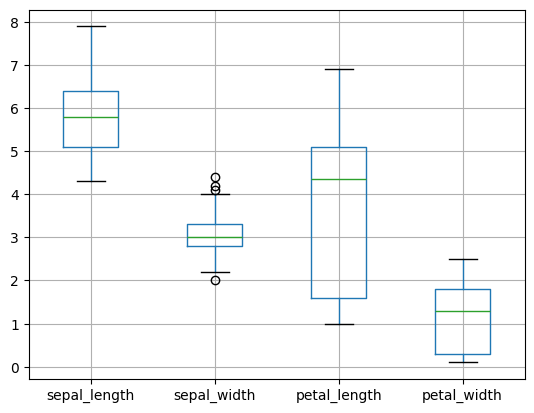

In [ ]:
import seaborn as sns
df=sns.load_dataset('iris')

df.boxplot()

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: >

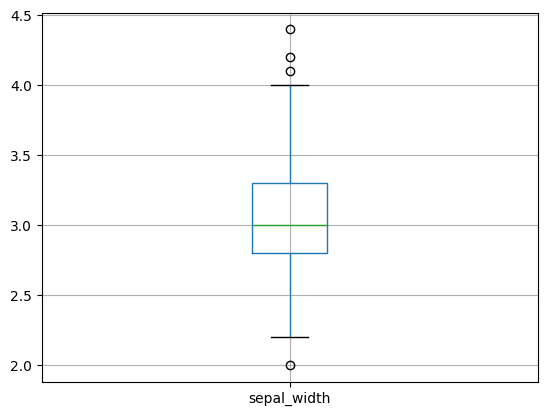

In [ ]:
df.boxplot(column='sepal_width')

#identify outliers

In [ ]:
import numpy as np
Q1=np.percentile(df['sepal_width'],25)
Q3=np.percentile(df['sepal_width'],75)
Q2=np.percentile(df['sepal_width'],50)

print(Q1,Q2,Q3)

IQR=Q3-Q1

low_lim=Q1-1.5*IQR
up_lim=Q3+1.5*IQR



2.8 3.0 3.3


#outliers trimming

In [ ]:
df_trim=df[(df['sepal_width']>=low_lim) & (df['sepal_width']<=up_lim)]

df_trim.shape

(146, 5)

<Axes: >

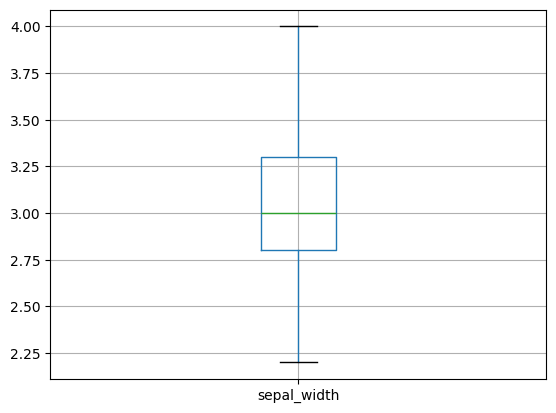

In [ ]:
df_trim.boxplot(column='sepal_width')

#outliers capping

df_cap = df.copy()

Creates a copy of df and stores it in df_cap.

Why? To prevent modifying the original DataFrame (df) while applying capping.


Caps upper outliers in the sepal_width column.

**np.where(condition, new_value, original_value)**

If sepal_width is greater than up_lim → replace it with up_lim.

Otherwise, keep the original value.

Why? Ensures that extreme outliers do not distort the data distribution.



In [ ]:
df_cap=df.copy()

df_cap['sepal_width']=np.where(df_cap['sepal_width']>up_lim,up_lim,df_cap['sepal_width'])
df_cap['sepal_width']=np.where(df_cap['sepal_width']<low_lim,low_lim,df_cap['sepal_width'])

In [ ]:
df_cap.shape

(150, 5)

<Axes: >

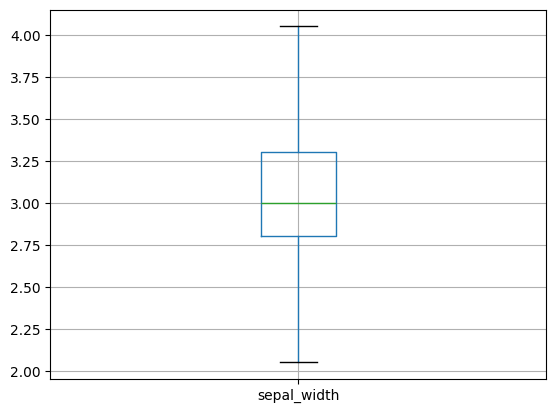

In [ ]:
df_cap.boxplot(column='sepal_width')


#**Nominal / one Hot encoding**

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
#create a simple DataFrame

df=pd.DataFrame(
    {
    'color':['red','blue','green','green','red','blue']
})
df

,color
0,red
1,blue
2,green
3,green
4,red
5,blue


In [ ]:
#create an instance of OneHotencoder

encoder=OneHotEncoder()
#perform fit and transform
encoded=encoder.fit_transform(df[['color']]).toarray()

print(encoded)

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


encoder.get_feature_names_out()
✅ Retrieves the feature (column) names after encoding.

When we apply One-Hot Encoding to categorical data, each unique category becomes a separate column.

get_feature_names_out() ensures that the new DataFrame has correct column names instead of default numeric indices.



In [ ]:
encoder_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

encoder_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


In [ ]:
df_new=pd.concat([df,encoder_df],axis=1)

df_new

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,blue,1.0,0.0,0.0


#**Label Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder
lbl_encoder=LabelEncoder()

lbl=lbl_encoder.fit_transform(df['color'])


lbl

array([2, 0, 1, 1, 2, 0])

In [ ]:
type(lbl)

numpy.ndarray

This line transforms the categorical value 'red' into its corresponding encoded numerical value using lbl_encoder, which is likely an instance of LabelEncoder or LabelBinarizer.

In [ ]:
lbl_encoder.transform([['red']])

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([2])

In [ ]:
lbl_encoder.transform([['blue']])

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([0])

In [ ]:
lbl_encoder.transform([['green']])

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([1])

In [ ]:
df['label_encoded']=lbl

df

,color,label_encoded
0,red,2
1,blue,0
2,green,1
3,green,1
4,red,2
5,blue,0


In [ ]:
df_new['label_encoded']=lbl

df_new

,color,color_blue,color_green,color_red,label_encoded
0,red,0.0,0.0,1.0,2
1,blue,1.0,0.0,0.0,0
2,green,0.0,1.0,0.0,1
3,green,0.0,1.0,0.0,1
4,red,0.0,0.0,1.0,2
5,blue,1.0,0.0,0.0,0


#**Ordinal Encoding**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

df=pd.DataFrame({
    'size':['small','medium','large','medium','small','large']
})

df

,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [ ]:
#create an instance of OrdinalEncoder and then fit_transform

encoder=OrdinalEncoder(categories=[['small','medium','large']])

lbl=encoder.fit_transform(df[['size']])

lbl

array([[0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [2.]])

In [ ]:
encoder.transform([['small']])

df

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [ ]:
df['size_encoded']=lbl

df

,size,size_encoded
0,small,0.0
1,medium,1.0
2,large,2.0
3,medium,1.0
4,small,0.0
5,large,2.0


#**Target guided Ordinal Encoding**

In [ ]:
import pandas as pd
 #create a sample dataframe with a categorical variable and a target variable

df=pd.DataFrame({
     'city':['New York','London','Paris','Tokyo','New York','Paris'],
     'price':[200,150,300,250,150,300]
})

df

,city,price
0,New York,200
1,London,150
2,Paris,300
3,Tokyo,250
4,New York,150
5,Paris,300


his code calculates the average (mean) price for each unique city in the df DataFrame.

In [ ]:
df.groupby('city')['price'].mean()

,price
city,
London,150.0
New York,175.0
Paris,300.0
Tokyo,250.0


In [ ]:
mean_price=df.groupby('city')['price'].mean().to_dict()

mean_price

{'London': 150.0, 'New York': 175.0, 'Paris': 300.0, 'Tokyo': 250.0}

In [ ]:
df['city_encoded']=df['city'].map(mean_price)
df

,city,price,city_encoded
0,New York,200,175.0
1,London,150,150.0
2,Paris,300,300.0
3,Tokyo,250,250.0
4,New York,150,175.0
5,Paris,300,300.0
